In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 1: FIX PILLOW + INSTALL LIBRARIES + IMPORT MODULES
# ═══════════════════════════════════════════════════════════════

# 1. Gỡ Pillow cũ & Cài bản ổn định
!pip uninstall -y pillow
!pip install pillow==10.4.0

# 2. Cài Diffusers, Transformers, ControlNet và các thư viện hỗ trợ
!pip install -q diffusers transformers accelerate peft xformers bitsandbytes safetensors opencv-python

# 3. Cài BLIP (để tự động caption ảnh train)
!pip install -q git+https://github.com/salesforce/BLIP

import torch
import torch.nn.functional as F
from diffusers import (
    StableDiffusionPipeline,
    DDPMScheduler,
    StableDiffusionControlNetPipeline,
    ControlNetModel,
    UniPCMultistepScheduler
)
from peft import LoraConfig, get_peft_model, PeftModel
from PIL import Image
import os
import numpy as np
from tqdm.auto import tqdm
from google.colab import drive, files
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import cv2

# Import BLIP
from transformers import BlipProcessor, BlipForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Libraries installed! Device: {device}")

Found existing installation: pillow 10.4.0
Uninstalling pillow-10.4.0:
  Successfully uninstalled pillow-10.4.0
  Using cached pillow-10.4.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (9.2 kB)
Using cached pillow-10.4.0-cp312-cp312-manylinux_2_28_x86_64.whl (4.5 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchvision 0.24.0+cu126 requires torch==2.9.0, but you have torch 2.9.1 which is incompatible.


ERROR: git+https://github.com/salesforce/BLIP does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.
✅ Libraries installed! Device: cuda


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 2: MOUNT DRIVE & CONFIG
# ═══════════════════════════════════════════════════════════════

drive.mount('/content/drive')

# --- CONFIGURATION ---
# Đường dẫn chứa ảnh style của bạn (JPG/PNG)
STYLE_FOLDER = "/content/drive/MyDrive/NguyenGiaTri/20_nguyengiatri_style"
# Nơi lưu model sau khi train
OUTPUT_DIR = "/content/drive/MyDrive/NguyenGiaTri/nguyengiatri_model"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Hyperparameters (Đã tinh chỉnh cho Sơn mài)
LEARNING_RATE = 1e-4    # Tăng nhẹ để học texture nhanh hơn
TRAIN_STEPS = 1500      # Số bước train
RESOLUTION = 512        # Kích thước ảnh
LORA_RANK = 32          # Tăng Rank để học chi tiết vết nứt/vàng thếp tốt hơn
CHECKPOINT_EVERY = 500  # Lưu checkpoint mỗi 500 bước

print(f"📁 Dataset: {STYLE_FOLDER}")
print(f"💾 Output: {OUTPUT_DIR}")

Mounted at /content/drive
📁 Dataset: /content/drive/MyDrive/NguyenGiaTri/20_nguyengiatri_style
💾 Output: /content/drive/MyDrive/NguyenGiaTri/nguyengiatri_model


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 3: LOAD DATA + DATA AUGMENTATION (X2 DATA)
# ═══════════════════════════════════════════════════════════════

# 1. Load Model Base
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16).to(device)

vae = pipe.vae
tokenizer = pipe.tokenizer
text_encoder = pipe.text_encoder
vae.requires_grad_(False)
text_encoder.requires_grad_(False)
del pipe

# 2. Load BLIP Captioning
print("⏳ Loading BLIP for auto-captioning...")
caption_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
caption_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base", torch_dtype=torch.float16).to(device)

# --- HÀM XỬ LÝ 1 ẢNH ĐƠN LẺ ---
def encode_single_image(img):
    # Resize & Center Crop vuông
    w, h = img.size
    min_dim = min(w, h)
    img_cropped = img.crop(((w-min_dim)//2, (h-min_dim)//2, (w+min_dim)//2, (h+min_dim)//2))
    img_resized = img_cropped.resize((RESOLUTION, RESOLUTION), Image.LANCZOS)

    # To Tensor & Normalize
    pixel_values = np.array(img_resized).astype(np.float32) / 255.0
    pixel_values = torch.from_numpy(pixel_values).permute(2, 0, 1).unsqueeze(0)
    pixel_values = 2.0 * pixel_values - 1.0
    pixel_values = pixel_values.to(device, dtype=torch.float16)

    # Encode sang Latent
    with torch.no_grad():
        latent = vae.encode(pixel_values).latent_dist.sample()
        latent = latent * vae.config.scaling_factor

    # Captioning
    inputs = caption_processor(img_resized, return_tensors="pt").to(device, torch.float16)
    out = caption_model.generate(**inputs, max_length=50)
    content_caption = caption_processor.decode(out[0], skip_special_tokens=True)

    # Tạo Prompt đầy đủ
    full_prompt = f"nguyen gia tri style, vietnamese lacquer painting, {content_caption}"

    # Encode Text
    tokens = tokenizer(
        full_prompt, padding="max_length", max_length=tokenizer.model_max_length,
        truncation=True, return_tensors="pt"
    ).input_ids.to(device)

    with torch.no_grad():
        text_emb = text_encoder(tokens)[0]

    return {"latent": latent, "text_emb": text_emb, "caption": full_prompt}

# 3. HÀM DUYỆT FOLDER VÀ AUGMENTATION
def process_data_with_augmentation(folder):
    dataset = []
    valid_ext = ('.png', '.jpg', '.jpeg')
    files = [f for f in os.listdir(folder) if f.lower().endswith(valid_ext)]
    print(f"🔄 Found {len(files)} original images. Processing with Augmentation...")

    for filename in tqdm(files):
        path = os.path.join(folder, filename)
        try:
            # Load ảnh gốc
            img_original = Image.open(path).convert("RGB")

            # --- 1. XỬ LÝ ẢNH GỐC ---
            data_orig = encode_single_image(img_original)
            dataset.append(data_orig)

            # --- 2. DATA AUGMENTATION: LẬT NGANG (FLIP) ---
            # Chỉ nên lật ngang, KHÔNG lật dọc hay xoay (vì sẽ làm sai trọng lực tranh)
            img_flipped = img_original.transpose(Image.FLIP_LEFT_RIGHT)
            data_flip = encode_single_image(img_flipped)
            dataset.append(data_flip)

        except Exception as e:
            print(f"⚠️ Error {filename}: {e}")

    return dataset

# Chạy xử lý
processed_dataset = process_data_with_augmentation(STYLE_FOLDER)
print(f"✅ DONE! Total dataset size (Original + Augmented): {len(processed_dataset)} items")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

merges.txt: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

🔄 Found 72 original images. Processing with Augmentation...


  0%|          | 0/72 [00:00<?, ?it/s]

✅ DONE! Total dataset size (Original + Augmented): 144 items


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 4: SETUP UNET & LORA CONFIG
# ═══════════════════════════════════════════════════════════════

# 1. Load UNet & Noise Scheduler
unet = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16).unet.to(device)
noise_scheduler = DDPMScheduler.from_pretrained(model_id, subfolder="scheduler")
unet.requires_grad_(False) # Freeze gốc

# 2. Config LoRA
lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_RANK,
    init_lora_weights="gaussian",
    target_modules=["to_k", "to_q", "to_v", "to_out.0"], # Train Attention layers
)

# 3. Add LoRA to UNet
unet = get_peft_model(unet, lora_config)
unet.print_trainable_parameters()

# 4. Optimizer
optimizer = torch.optim.AdamW(
    unet.parameters(),
    lr=LEARNING_RATE,
    betas=(0.9, 0.999),
    weight_decay=1e-2
)

# Scheduler giảm dần LR
from torch.optim.lr_scheduler import CosineAnnealingLR
lr_scheduler = CosineAnnealingLR(optimizer, T_max=TRAIN_STEPS, eta_min=1e-6)

print("✅ LoRA Model Ready for Training!")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

trainable params: 6,377,472 || all params: 865,898,436 || trainable%: 0.7365
✅ LoRA Model Ready for Training!


Training LoRA:   0%|          | 0/1500 [00:00<?, ?it/s]

 -> Checkpoint saved at step 500
 -> Checkpoint saved at step 1000
 -> Checkpoint saved at step 1500


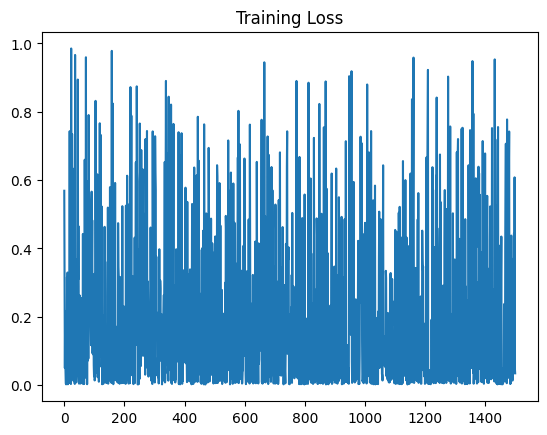

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 5: TRAINING LOOP
# ═══════════════════════════════════════════════════════════════

unet.train()
global_step = 0
losses = []
progress_bar = tqdm(total=TRAIN_STEPS, desc="Training LoRA")

while global_step < TRAIN_STEPS:
    # 1. Chọn ngẫu nhiên 1 ảnh từ dataset
    idx = np.random.randint(0, len(processed_dataset))
    data_item = processed_dataset[idx]

    latent = data_item["latent"]      # [1, 4, 64, 64]
    text_emb = data_item["text_emb"]  # [1, 77, 768]

    # 2. Add Noise
    noise = torch.randn_like(latent)
    timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (1,), device=device).long()
    noisy_latent = noise_scheduler.add_noise(latent, noise, timesteps)

    # 3. Predict Noise (Forward pass)
    # Lưu ý: model output là struct, lấy .sample
    noise_pred = unet(noisy_latent, timesteps, encoder_hidden_states=text_emb).sample

    # 4. Tính Loss & Backprop
    loss = F.mse_loss(noise_pred.float(), noise.float())

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(unet.parameters(), 1.0)
    optimizer.step()
    lr_scheduler.step()

    # 5. Log & Save
    global_step += 1
    losses.append(loss.item())

    progress_bar.set_postfix({"loss": f"{loss.item():.4f}"})
    progress_bar.update(1)

    if global_step % CHECKPOINT_EVERY == 0:
        save_path = os.path.join(OUTPUT_DIR, f"checkpoint-{global_step}")
        unet.save_pretrained(save_path)
        print(f" -> Checkpoint saved at step {global_step}")

progress_bar.close()

# Vẽ biểu đồ Loss
plt.plot(losses)
plt.title("Training Loss")
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 6: SAVE FINAL MODEL
# ═══════════════════════════════════════════════════════════════
unet.save_pretrained(OUTPUT_DIR)
print(f"🎉 Training Done! Model saved to: {OUTPUT_DIR}")

🎉 Training Done! Model saved to: /content/drive/MyDrive/NguyenGiaTri/nguyengiatri_model


⏳ Loading ControlNet Pipeline...


config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .



📤 Upload ảnh bạn muốn chuyển thành tranh sơn mài:


Saving anhphongcanhdetest.jpg to anhphongcanhdetest.jpg
🎨 Generating...


  0%|          | 0/30 [00:00<?, ?it/s]

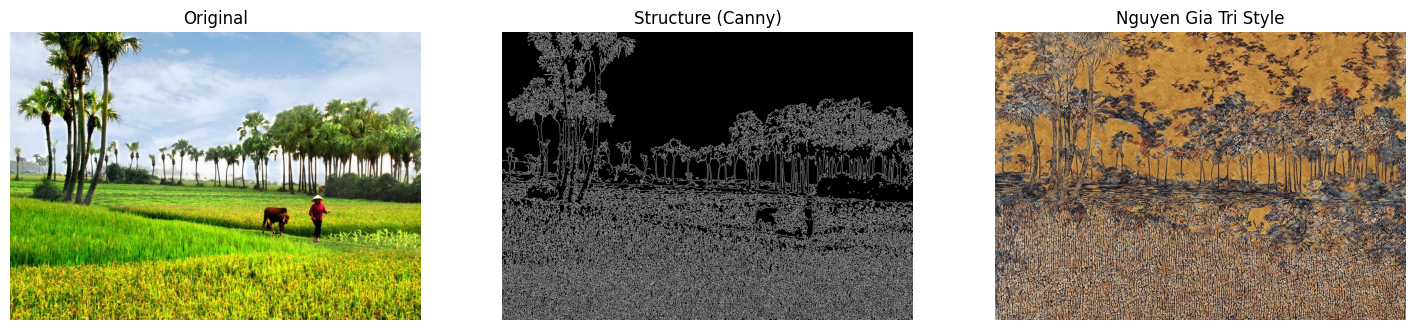

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 7: INFERENCE WITH CONTROLNET (BEST FOR STYLE TRANSFER)
# ═══════════════════════════════════════════════════════════════

# 1. Load ControlNet & Pipeline
print("⏳ Loading ControlNet Pipeline...")
controlnet = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-canny", torch_dtype=torch.float16)

pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16,
    safety_checker=None
).to(device)

# Load LoRA vừa train vào pipeline
pipe.unet = PeftModel.from_pretrained(pipe.unet, OUTPUT_DIR)
pipe.unet.merge_and_unload() # Merge LoRA vào model chính để chạy mượt hơn

pipe.scheduler = UniPCMultistepScheduler.from_pretrained("runwayml/stable-diffusion-v1-5", subfolder="scheduler")
pipe.enable_model_cpu_offload() # Tiết kiệm VRAM

# 2. Upload Ảnh Test
print("\n📤 Upload ảnh bạn muốn chuyển thành tranh sơn mài:")
uploaded = files.upload()

if uploaded:
    filename = list(uploaded.keys())[0]
    init_image = Image.open(filename).convert("RGB")

    # Resize ảnh về kích thước hợp lý (chia hết cho 8)
    w, h = init_image.size
    w, h = (w // 8) * 8, (h // 8) * 8
    init_image = init_image.resize((w, h))

    # 3. Tạo Canny Map (Nét vẽ)
    image_cv = np.array(init_image)
    # Phát hiện cạnh (Canny Edge Detection)
    canny_image = cv2.Canny(image_cv, 100, 200)
    canny_image = canny_image[:, :, None]
    canny_image = np.concatenate([canny_image, canny_image, canny_image], axis=2)
    canny_pil = Image.fromarray(canny_image)

    # 4. Generate
    # Tự động tạo prompt (hoặc bạn có thể tự nhập)
    prompt = "nguyen gia tri style, vietnamese lacquer painting, gold leaf texture, eggshell mosaic, warm tones, traditional art, masterpiece"
    negative_prompt = "photo, realistic, 3d, bad anatomy, blurry, low quality"

    print("🎨 Generating...")
    result = pipe(
        prompt,
        image=canny_pil, # ControlNet input
        negative_prompt=negative_prompt,
        num_inference_steps=30,
        guidance_scale=9.0, # Độ bám sát style
        controlnet_conditioning_scale=0.9 # 0.7 = Giữ nét 70%, 30% sáng tạo
    ).images[0]

    # 5. Hiển thị
    display(HTML("<h3>Original - Canny Edge - Result</h3>"))

    # Hiển thị side-by-side
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    axs[0].imshow(init_image); axs[0].set_title("Original"); axs[0].axis('off')
    axs[1].imshow(canny_pil); axs[1].set_title("Structure (Canny)"); axs[1].axis('off')
    axs[2].imshow(result); axs[2].set_title("Nguyen Gia Tri Style"); axs[2].axis('off')
    plt.show()